In [3]:
from embodied_agent.init_agent_env_and_create_agent import init_agent_env_and_create_agent
from embodied_agent import spf_tools
agent = init_agent_env_and_create_agent()
ctrl = spf_tools._control

GOOGLE模型 gemini-2.5-pro 加载成功, TEMP=0.7
[embodied_agent] 智能体已与ROS2环境及大模型成功绑定


[INFO] [1780380300.046234291] [info_node]: [InfoNode] 启动完成
[INFO] [1780380300.049297680] [navigation_node]: [NavigationNode] 初始化: horizon=15, nav_speed=1.0, dt=0.1, target_z=1.0
[INFO] [1780380300.050656874] [navigation_node]: [NavigationNode] 启动完成
[INFO] [1780380300.157267937] [navigation_node]: [NavigationNode] FSM 状态变化: '' -> 'hover_start'
[INFO] [1780380317.521047639] [navigation_node]: [NavigationNode] FSM 状态变化: 'hover_start' -> 'tracking'


In [6]:
# --- 测试 get_agent_state() ---
state = ctrl.get_agent_state()
print("Pos:", state["position"])
print("Yaw:", state["rotation"])

Pos: {'x': 0.8531865477561951, 'y': -0.7881931066513062, 'z': 0.99298095703125}
Yaw: {'roll': 0.05477374483455432, 'pitch': 359.8271188494807, 'yaw': 314.92381053416364}


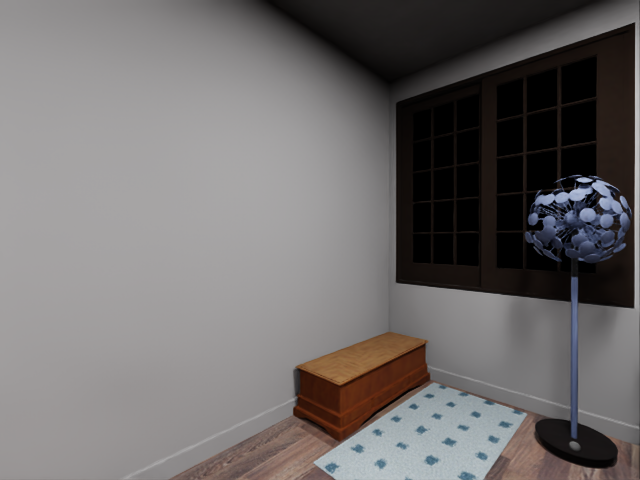

In [7]:
# --- 测试 get_current_view() ---
from PIL import Image
img: Image.Image = ctrl.get_current_view()
display(img)

In [5]:
# --- 测试 navigate_to_point() ---
state = ctrl.get_agent_state()
print("当前状态:", state)
cx, cy, cz = state["position"]["x"], state["position"]["y"], state["position"]["z"]
yaw = state["rotation"]["yaw"]
print(f"当前位置: x={cx:.2f}, y={cy:.2f}, z={cz:.2f}")

result = ctrl.navigate_to_point({
    "x": cx + 0.7,
    "y": cy - 0.7,
    "z": cz
})
print("导航结果:", result)

当前状态: {'position': {'x': 0.15472610294818878, 'y': -0.09542284905910492, 'z': 0.9935684204101562}, 'rotation': {'roll': 359.92927478616684, 'pitch': 0.5335459154902779, 'yaw': 177.67990483286897}}
当前位置: x=0.15, y=-0.10, z=0.99


[INFO] [1780380351.081181770] [navigation_node]: [NavigationNode] 开始旋转, target_yaw=-0.785, current_yaw=3.099, yaw_diff=2.3983
[INFO] [1780380352.051824253] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.156,-0.098,0.995), yaw_diff=2.2803, target_yaw=-0.785, current_yaw=-3.066
[INFO] [1780380353.052110156] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.154,-0.119,1.016), yaw_diff=1.7676, target_yaw=-0.785, current_yaw=-2.553
[INFO] [1780380354.051728252] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.149,-0.148,1.026), yaw_diff=1.4073, target_yaw=-0.785, current_yaw=-2.193
[INFO] [1780380355.052603874] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.130,-0.159,1.011), yaw_diff=0.9629, target_yaw=-0.785, current_yaw=-1.748
[INFO] [1780380356.051730943] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.108,-0.145,0.991), yaw_diff=0.5442, target_yaw=-0.785, current_yaw=-1.330
[INFO] [1

导航结果: {'success': True, 'position': {'x': 0.8467689156532288, 'y': -0.7773857116699219, 'z': 0.98980712890625}, 'yaw': 314.9535816927779}


[INFO] [1780380384.052124811] [navigation_node]: [NavigationNode] moving: fsm='tracking', pos=(0.846,-0.777,0.990), target=(0.855,-0.795), dist_xy=0.020, yaw_cmd=-0.785
[INFO] [1780380384.091359086] [navigation_node]: [NavigationNode] 已到达目标点
[INFO] [1780380384.092675139] [navigation_node]: [NavigationNode] 切换到 HOLD 状态
[INFO] [1780380384.093195068] [navigation_node]: [NavigationNode] 导航完成


In [4]:
# --- 测试 navigate_to_point() ---
state = ctrl.get_agent_state()
print("当前状态:", state)
result = ctrl.rotate(180)
print("旋转结果:", result)


当前状态: {'position': {'x': 0.08806998282670975, 'y': -0.04530694708228111, 'z': 0.992950439453125}, 'rotation': {'roll': 0.1343969223812816, 'pitch': 0.06681755277929051, 'yaw': 0.22375462296334575}}


[INFO] [1780380328.963355581] [navigation_node]: [NavigationNode] 开始旋转, target_yaw=3.142, current_yaw=0.004, yaw_diff=3.1381
[INFO] [1780380329.052116919] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.088,-0.045,0.993), yaw_diff=3.1386, target_yaw=3.142, current_yaw=0.003
[INFO] [1780380330.051650955] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.092,-0.045,0.998), yaw_diff=2.9664, target_yaw=3.142, current_yaw=0.175
[INFO] [1780380331.052200423] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.092,-0.021,1.018), yaw_diff=2.4662, target_yaw=3.142, current_yaw=0.675
[INFO] [1780380332.052122986] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.098,0.012,1.023), yaw_diff=2.0767, target_yaw=3.142, current_yaw=1.065
[INFO] [1780380333.052123251] [navigation_node]: [NavigationNode] rotating: fsm='tracking', pos=(0.118,0.025,1.005), yaw_diff=1.6368, target_yaw=3.142, current_yaw=1.505
[INFO] [1780380334.051

旋转结果: {'success': True, 'position': {'x': 0.13360077142715454, 'y': -0.09840063005685806, 'z': 0.9951400756835938}, 'yaw': 177.62122520148114}


[INFO] [1780380336.871322668] [navigation_node]: [NavigationNode] 已到达目标偏航
[INFO] [1780380336.872944567] [navigation_node]: [NavigationNode] 切换到 HOLD 状态
[INFO] [1780380336.873431854] [navigation_node]: [NavigationNode] 旋转完成


In [2]:
ctrl.close()

正在关闭 ROS2Control 控制器并注销节点...
ROS2Control 控制器资源释放完毕
